In [ ]:
!pip install datasets

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
dataset = load_dataset("dair-ai/emotion")

train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

print(train_df.head())

                                                text  label
0                            i didnt feel humiliated      0
1  i can go from feeling so hopeless to so damned...      0
2   im grabbing a minute to post i feel greedy wrong      3
3  i am ever feeling nostalgic about the fireplac...      2
4                               i am feeling grouchy      3


In [ ]:
print(train_df.shape)
print(test_df.shape)

train_df['label'].value_counts()

(16000, 2)
(2000, 2)


,count
label,
1,5362
0,4666
3,2159
4,1937
2,1304
5,572


In [ ]:
emotion_names = {
    0:"sadness",
    1:"joy",
    2:"love",
    3:"anger",
    4:"fear",
    5:"surprise"
}

train_df["emotion"] = train_df["label"].map(emotion_names)
test_df["emotion"] = test_df["label"].map(emotion_names)

train_df.head()

,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


In [ ]:
encoder = LabelEncoder()

y_train = encoder.fit_transform(train_df["emotion"])
y_test = encoder.transform(test_df["emotion"])

In [ ]:
vocab_size = 10000

tokenizer = Tokenizer(num_words=vocab_size,
                      oov_token="")

tokenizer.fit_on_texts(train_df["text"])

In [ ]:
X_train = tokenizer.texts_to_sequences(train_df["text"])
X_test = tokenizer.texts_to_sequences(test_df["text"])


In [ ]:
max_length = 40

X_train = pad_sequences(X_train,
                        maxlen=max_length,
                        padding="post")

X_test = pad_sequences(X_test,
                       maxlen=max_length,
                       padding="post")

In [ ]:
model = Sequential()

model.add(
    Embedding(input_dim=vocab_size,
              output_dim=64,
              input_length=max_length)
)

model.add(
    LSTM(64)
)

model.add(
    Dropout(0.5)
)

model.add(
    Dense(32, activation="relu")
)

model.add(
    Dense(6, activation="softmax")
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=64
)

Epoch 1/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.3261 - loss: 1.6031 - val_accuracy: 0.3262 - val_loss: 1.5759
Epoch 2/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.3468 - loss: 1.4966 - val_accuracy: 0.4047 - val_loss: 1.2412
Epoch 3/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.4324 - loss: 1.1373 - val_accuracy: 0.4431 - val_loss: 1.1051
Epoch 4/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.5441 - loss: 0.9574 - val_accuracy: 0.6725 - val_loss: 0.8442
Epoch 5/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.7468 - loss: 0.6462 - val_accuracy: 0.7262 - val_loss: 0.6713
Epoch 6/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.8232 - loss: 0.4559 - val_accuracy: 0.7903 - val_loss: 0.5978
Epoch 7/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.9059 - loss: 0.2965 - val_accuracy: 0.8778 - val_loss: 0.4220
Epoch 8/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.9399 - loss: 0.1985 - val_accuracy:

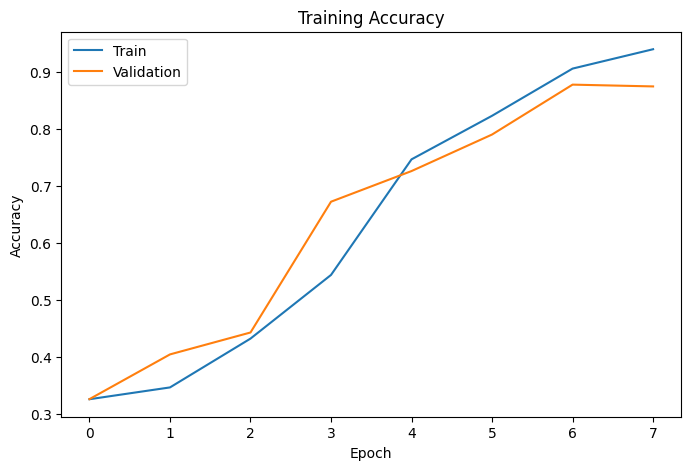

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")

plt.legend()
plt.show()



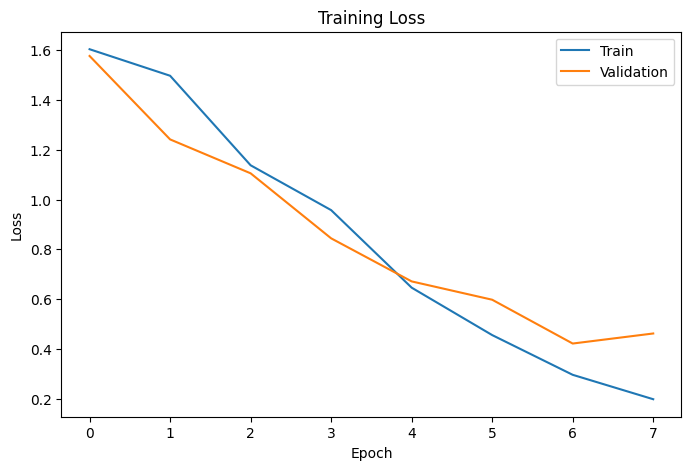

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.legend()
plt.show()


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy :", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8680 - loss: 0.4681
Test Accuracy : 0.8679999709129333


In [ ]:
pred = model.predict(X_test)

pred_classes = np.argmax(pred, axis=1)

print(classification_report(y_test, pred_classes))


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
              precision    recall  f1-score   support

           0       0.90      0.87      0.88       275
           1       0.87      0.76      0.81       224
           2       0.92      0.90      0.91       695
           3       0.58      0.85      0.69       159
           4       0.92      0.94      0.93       581
           5       0.52      0.26      0.34        66

    accuracy                           0.87      2000
   macro avg       0.79      0.76      0.76      2000
weighted avg       0.87      0.87      0.87      2000



In [ ]:
sentence = ["I feel like killing someone "]

seq = tokenizer.texts_to_sequences(sentence)
seq = pad_sequences(seq, maxlen=max_length, padding="post")

prediction = model.predict(seq)

emotion = encoder.inverse_transform([np.argmax(prediction)])

print("Predicted Emotion:", emotion[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Predicted Emotion: sadness
